In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
df = pd.read_csv("smartcart_customers.csv")


In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0


In [24]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

Data preprocessing

1.Handling Missing Value

In [25]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [26]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

Feature engineering

In [27]:
df["Age"]= df["Year_Birth"].max() - df["Year_Birth"]

In [28]:
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"]= (reference_date - df["Dt_Customer"]).dt.days

In [29]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [30]:
df["Total_Spending"]= df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [31]:
df["Total_Children"]= df["Kidhome"] + df["Teenhome"]

In [32]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [33]:
df["Education"]=df["Education"].replace({
    "2n Cycle":"UnderGraduate", "Basic":"UnderGraduate", "Graduation":"Graduate", "PhD":"PostGraduate", "Master":"PostGraduate"
})

In [34]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [35]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [36]:
df["Living_with"] = df["Marital_Status"].replace({
    "Married":"Partner", "Together":"Partner", "Single":"Alone", "Divorced":"Alone", "Widow":"Alone", "Absurd":"Alone", "YOLO":"Alone"

})

In [37]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

Dropping Columns

In [40]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_with'],
      dtype='object')

In [42]:
cols = ["ID", "Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds","Customer_Tenure_Days"]

df_cleaned = df.drop(columns=cols)

In [29]:
df_cleaned.shape

(2240, 15)

Outliers

In [43]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Total_Spending',
       'Total_Children', 'Living_with'],
      dtype='object')

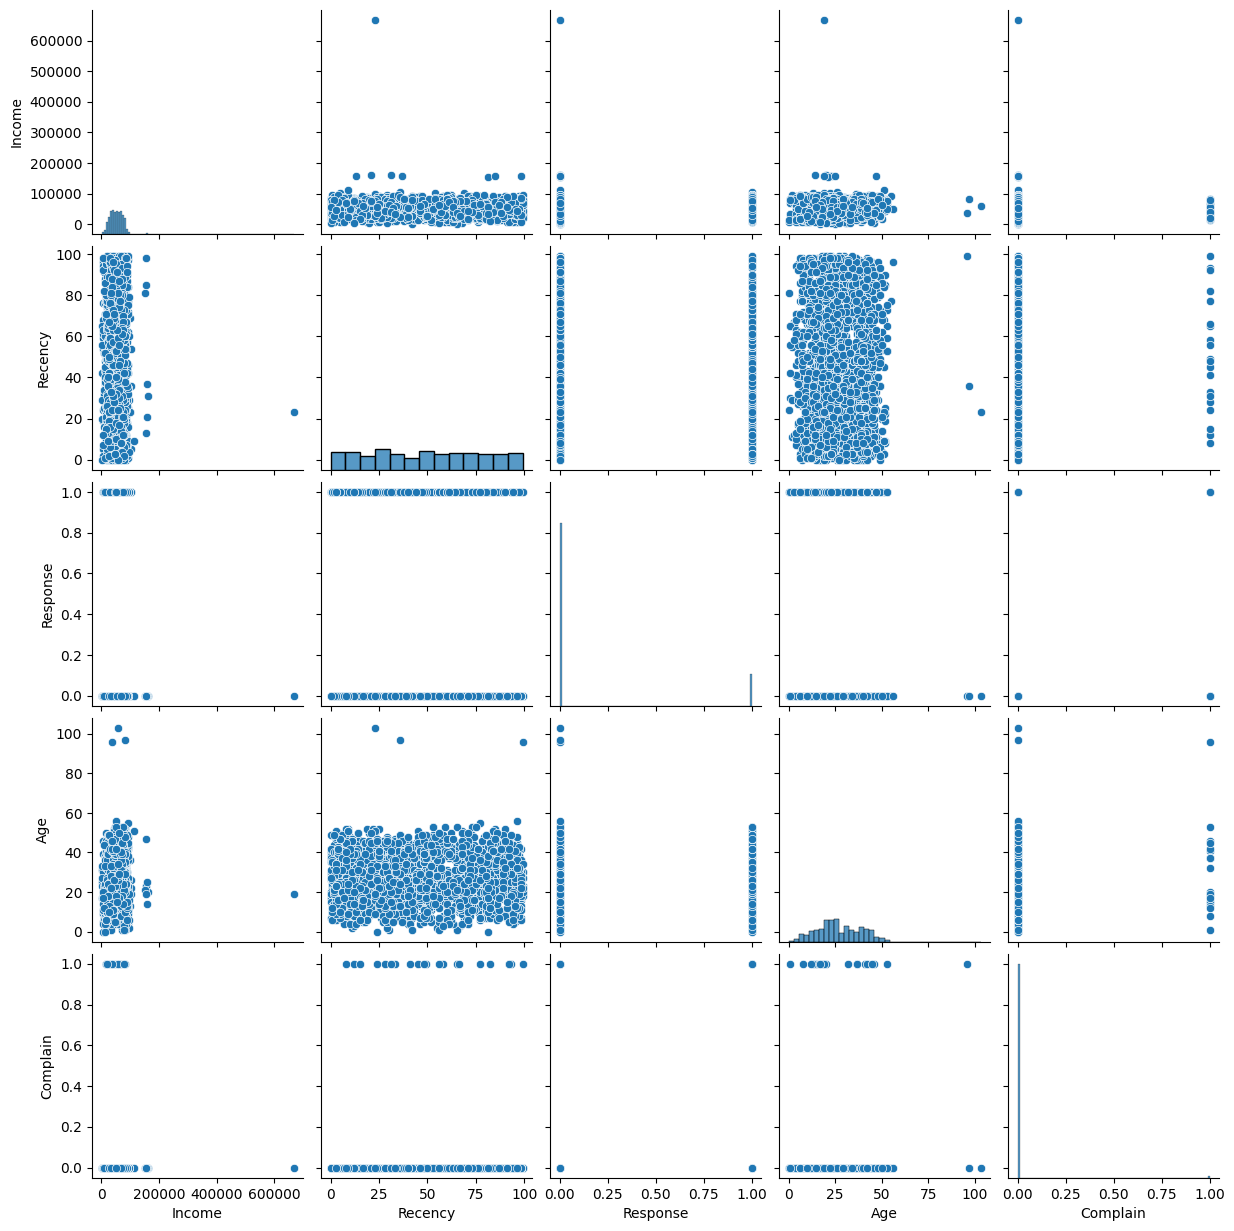

In [44]:
cols=["Income","Recency","Response","Age","Complain"]

sns.pairplot(df_cleaned[cols])

In [45]:
print("with outliers : " , len(df_cleaned))

df_cleaned= df_cleaned[df_cleaned["Age"]<90]
df_cleaned= df_cleaned[df_cleaned["Income"]<600000]
print("without outliers : ", len(df_cleaned))

with outliers :  2240
without outliers :  2236


Encoding

In [46]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])


In [47]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)

In [48]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis =1)

Scaling

In [50]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X= df_encoded

X_scaled = scalar.fit_transform(X)


Dimensionality reduction

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

Analysing K values

1. Elbow method

In [ ]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11) :
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [60]:
knee= KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [61]:
optimal_k

np.int64(4)

2. Silhouette Score

In [64]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans= KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'ss')

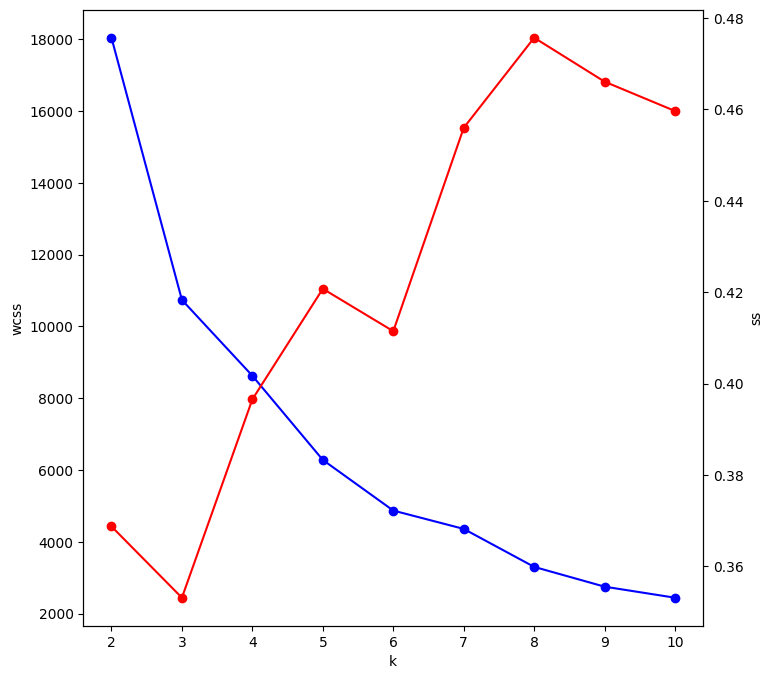

In [69]:
#combined plot

k_range = range(2,11)
fig,ax1=plt.subplots(figsize=(8,8))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="o",color="red")
ax2.set_ylabel("ss")

Clustering

In [ ]:
# finalising k=4


1. KMeans

In [70]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)


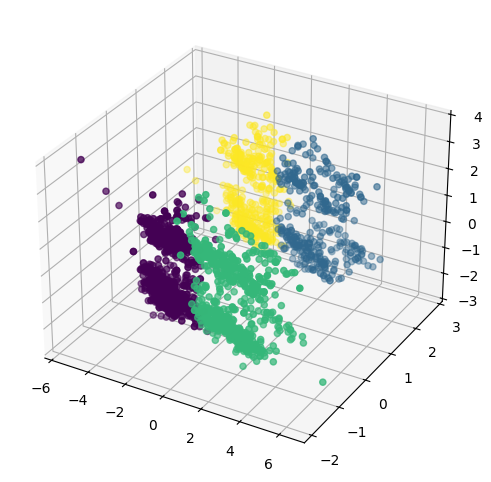

In [74]:
fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

2. Agglomerative clustering

In [75]:
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)


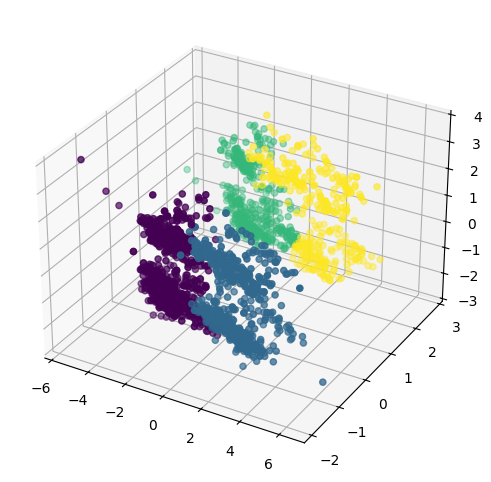

In [76]:
fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [81]:
X["clusters"]=labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_with_Alone,Living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,39,1445,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,42,25,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,31,665,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,12,43,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,15,376,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

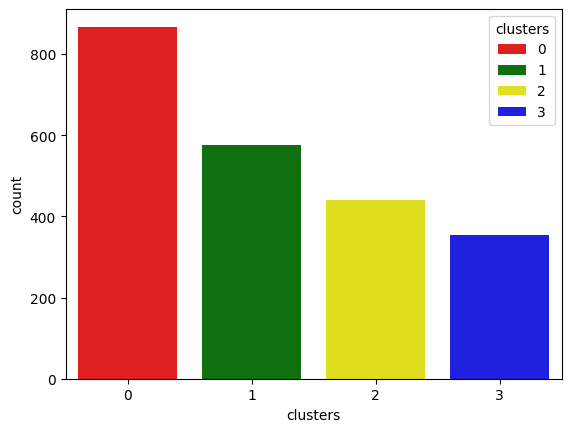

In [82]:
pal = ["red","green","yellow","blue"]
sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

In [83]:
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  ...  Living_with_Alone  Living_with_Partner
clusters                           ...                                        
0         38645.906574  48.982699  ...                0.0                  1.0
1         71828.069565  49.125217  ...                0.0                  1.0
2         38274.113895  48.000000  ...                1.0                  0.0
3         69173.430986  50.808451  ...                1.0                  0.0

[4 rows x 17 columns]
